In [1]:
import os
from pathlib import Path
os.chdir(Path(os.getcwd()).parent)

In [2]:
import os
import time
import pandas as pd
import cvxpy as cp
from pathlib import Path
from Code.Plotting import DPhil_Plotting
from Code.Network.Network import Network_STEVFNs

case_study_name = "ID-PH-SG_Collab"
case_study_name = "ID-MY-SG_Collab"
case_study_name = "MY-PH-SG_Collab"

base_folder = Path(os.getcwd())
data_folder = os.path.join(base_folder, "Data")
case_study_folder = os.path.join(data_folder, "Case_Study", case_study_name)
scenario_folders_list = [x[0] for x in os.walk(case_study_folder)][1:]
network_structure_filename = os.path.join(case_study_folder, "Network_Structure.csv")
results_filename = os.path.join(case_study_folder, "total_data.csv")
website_total_data_filename = os.path.join(case_study_folder, "total_data_unrounded.csv")
capacities_filename = os.path.join(case_study_folder, "capacities_total_data.csv")
unrounded_results_filename = os.path.join(case_study_folder, "internal_total_data.csv")

network_structure_df = pd.read_csv(network_structure_filename)

print("========================== Building ==========================")
start_time0 = time.time()
my_network = Network_STEVFNs()
my_network.build(network_structure_df)
end_time = time.time()
print("Time taken to build network = ", end_time - start_time0, "s")

results = list()
for counter1 in range(len(scenario_folders_list)):

    scenario_folder = scenario_folders_list[-1-counter1]
    asset_parameters_filename = os.path.join(scenario_folder, "Asset_Parameters.csv")
    location_parameters_filename = os.path.join(scenario_folder, "Location_Parameters.csv")
    system_parameters_filename = os.path.join(scenario_folder, "System_Parameters.csv")

    asset_parameters_df = pd.read_csv(asset_parameters_filename)
    location_parameters_df = pd.read_csv(location_parameters_filename)
    system_parameters_df = pd.read_csv(system_parameters_filename)
    my_network.scenario_name = os.path.basename(scenario_folder)

    print(f"\n================== Updating for Scenario {my_network.scenario_name} ==================\n")
    start_time = time.time()
    my_network.update(location_parameters_df, asset_parameters_df, system_parameters_df)
    end_time = time.time()
    print("Time taken to update network = ", end_time - start_time, "s")

    start_time = time.time()
    solver_name = "CLARABEL"
    if solver_name == "CLARABEL":
        my_network.problem.solve(solver=cp.CLARABEL, max_iter=10000, ignore_dpp=True)
    elif solver_name == "MOSEK":
        my_network.problem.solve(solver=cp.MOSEK, ignore_dpp=True)
    else:
        raise ValueError(f"Unknown solver: {solver_name}")
    end_time = time.time()

    print(f"----------------- Scenario {my_network.scenario_name} Main Results ----------------------\n")
    print("Time taken to solve problem = ", end_time - start_time, "s")
    print(my_network.problem.solution.status) # type: ignore
    if my_network.problem.value == float("inf"):
        continue
    print("Total cost to satisfy all demand = ", my_network.problem.value, " Billion USD")
    print("Total emissions = ", my_network.assets[0].asset_size(), "MtCO2e")

    artist = DPhil_Plotting.plot_asset_sizes(my_network)
    results.append({
        "uid": f"S-{my_network.scenario_name}",
        "cost": my_network.problem.value,
        "emissions": my_network.assets[0].asset_size(),
        "artist": artist
    })

========================== Building ==========================


/home/jpacilo/Developer/ce2m/urbs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


Time taken to build network =  33.89854192733765 s

================== Updating for Scenario 30 ==================

Time taken to update network =  0.11752891540527344 s


/home/jpacilo/Developer/ce2m/urbs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/urbs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #63 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/urbs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #111 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


----------------- Scenario 30 Main Results ----------------------

Time taken to solve problem =  28.095715761184692 s
optimal
Total cost to satisfy all demand =  697.0863811958739  Billion USD
Total emissions =  1140.0000030945719 MtCO2e

================== Updating for Scenario 0 ==================

Time taken to update network =  0.10342860221862793 s


...

----------------- Scenario 70 Main Results ----------------------

Time taken to solve problem =  26.078622341156006 s
optimal
Total cost to satisfy all demand =  637.9948354766685  Billion USD
Total emissions =  2280.0000001118256 MtCO2e

================== Updating for Scenario 20 ==================

Time taken to update network =  0.12446117401123047 s


/home/jpacilo/Developer/ce2m/urbs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/urbs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #63 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/urbs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #111 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


----------------- Scenario 20 Main Results ----------------------

Time taken to solve problem =  25.288837909698486 s
optimal
Total cost to satisfy all demand =  708.0987907194562  Billion USD
Total emissions =  1020.000003362916 MtCO2e

================== Updating for Scenario 80 ==================

Time taken to update network =  0.10384345054626465 s


/home/jpacilo/Developer/ce2m/urbs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/urbs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #63 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/urbs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #111 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


----------------- Scenario 80 Main Results ----------------------

Time taken to solve problem =  24.743864059448242 s
optimal
Total cost to satisfy all demand =  626.186418192721  Billion USD
Total emissions =  2660.0000001217413 MtCO2e


In [3]:
feature = "EL_Transport"

df_results = pd.DataFrame(results)
df_results["EL_Transport"] = df_results.artist.apply(lambda x: x.bar_data_dict[feature]["height"][0])
df_results.drop(columns="artist").to_csv(f"{case_study_name}__{feature}.csv", index=False)

In [4]:
df_results.drop(columns="artist")

,uid,cost,emissions,EL_Transport
0,S-30,697.086381,1140.000003,9.221754
1,S-0,796.483822,380.499806,10.549032
2,S-10,737.300227,760.999600,9.483458
3,S-60,646.451265,2040.000000,9.743609
4,S-40,669.125947,1520.000001,9.169655
5,S-BAU,933.041154,0.000026,13.166097
6,S-90,616.622383,3040.000000,11.946669
7,S-50,651.833970,1900.000000,9.401815
8,S-70,637.994835,2280.000000,9.840731
9,S-20,708.098791,1020.000003,8.944317


In [5]:
df_results = df_results.sort_values(by="uid")
df_results.reset_index(drop=True, inplace=True)

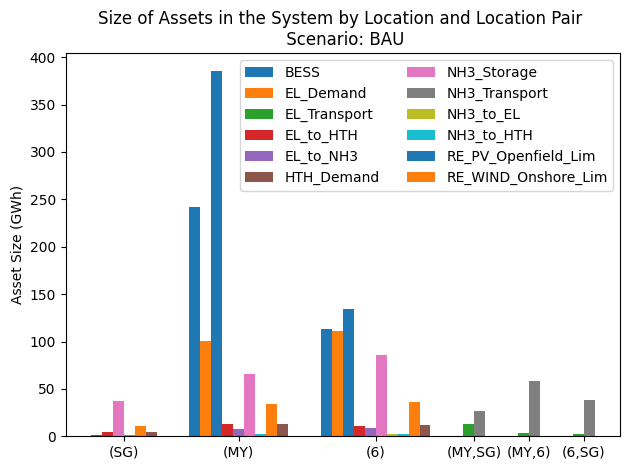

In [6]:
my_artist = df_results.loc[len(df_results)-1, "artist"]

bar_width = 1.0
bar_spacing = 4.0
my_artist.plot(bar_width, bar_spacing)

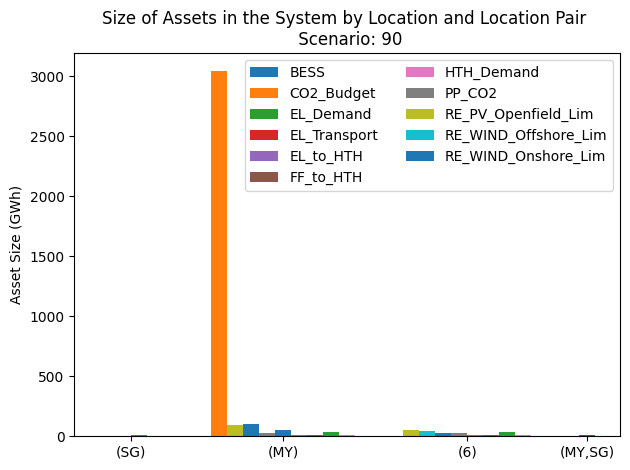

In [7]:
my_artist = df_results.loc[len(df_results)-2, "artist"]

bar_width = 1.0
bar_spacing = 4.0
my_artist.plot(bar_width, bar_spacing)

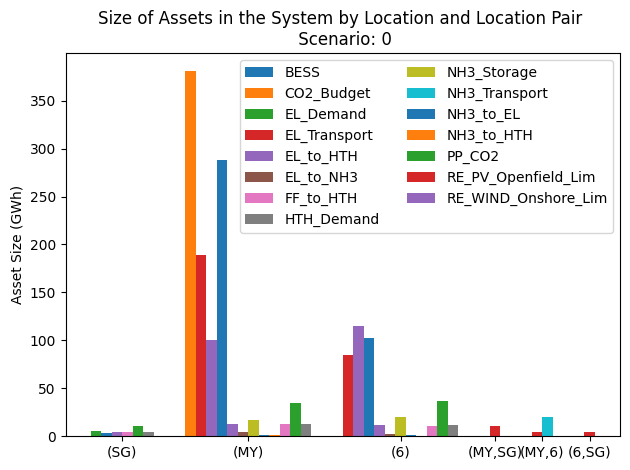

In [8]:
my_artist = df_results.loc[0, "artist"]

bar_width = 1.0
bar_spacing = 4.0
my_artist.plot(bar_width, bar_spacing)